### CKD Model Hyperparameter Tuning and Comparission of Original Vs Tuned Models

#### Import libraries 

In [1]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Suppress numeric runtime warnings from model fitting for clean notebook output.
warnings.filterwarnings("ignore", category=RuntimeWarning)

sns.set_theme(style="whitegrid")
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


#### Load the processed training and testing datasets.

In [2]:
# Target column for the model.
targetColumn = "ckdDiagnosis"

# Load unscaled feature data for tree-based models.
XTrain = pd.read_csv("dataset/XTrain.csv")
XTest = pd.read_csv("dataset/XTest.csv")

# Load scaled feature data for Logistic Regression.
XTrainScaled = pd.read_csv("dataset/XTrainScaled.csv")
XTestScaled = pd.read_csv("dataset/XTestScaled.csv")

# Load target values as one-dimensional Series objects.
yTrain = pd.read_csv("dataset/yTrain.csv")[targetColumn]
yTest = pd.read_csv("dataset/yTest.csv")[targetColumn]

print(f"XTrain shape: {XTrain.shape}")
print(f"XTest shape: {XTest.shape}")
print(f"XTrainScaled shape: {XTrainScaled.shape}")
print(f"XTestScaled shape: {XTestScaled.shape}")
print(f"yTrain shape: {yTrain.shape}")
print(f"yTest shape: {yTest.shape}")

XTrain shape: (37160, 19)
XTest shape: (9290, 19)
XTrainScaled shape: (37160, 19)
XTestScaled shape: (9290, 19)
yTrain shape: (37160,)
yTest shape: (9290,)


#### Hyperparameter Tuning: Using GridSearchCV with stratified 5-fold cross-validation and ROC-AUC scoring.

In [3]:
# Use the same cross-validation approach for all models.
crossValidation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logisticRegressionParameters = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

randomForestParameters = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

xGBoostParameters = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0]
}

# Define the base models before tuning.
logisticRegressionBaseModel = LogisticRegression(
    max_iter=1000,
    random_state=42
)

randomForestBaseModel = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

xGBoostBaseModel = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [4]:
# Tune Logistic Regression using scaled features.
logisticRegressionGridSearch = GridSearchCV(
    estimator=logisticRegressionBaseModel,
    param_grid=logisticRegressionParameters,
    scoring="roc_auc",
    cv=crossValidation,
    n_jobs=1
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    logisticRegressionGridSearch.fit(XTrainScaled, yTrain)

print("Best Logistic Regression parameters:")
print(logisticRegressionGridSearch.best_params_)
print(f"Best Logistic Regression CV ROC-AUC: {logisticRegressionGridSearch.best_score_:.4f}")

Best Logistic Regression parameters:
{'C': 0.1, 'solver': 'liblinear'}
Best Logistic Regression CV ROC-AUC: 0.9629


In [5]:
# Tune Random Forest using unscaled features.
randomForestGridSearch = GridSearchCV(
    estimator=randomForestBaseModel,
    param_grid=randomForestParameters,
    scoring="roc_auc",
    cv=crossValidation,
    n_jobs=1
)
randomForestGridSearch.fit(XTrain, yTrain)


print("Best Random Forest parameters:")
print(randomForestGridSearch.best_params_)
print(f"Best Random Forest CV ROC-AUC: {randomForestGridSearch.best_score_:.4f}")

Best Random Forest parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV ROC-AUC: 0.9650


In [6]:
# Tune XGBoost using unscaled features.
xGBoostGridSearch = GridSearchCV(
    estimator=xGBoostBaseModel,
    param_grid=xGBoostParameters,
    scoring="roc_auc",
    cv=crossValidation,
    n_jobs=1
)
xGBoostGridSearch.fit(XTrain, yTrain)

print("Best XGBoost parameters:")
print(xGBoostGridSearch.best_params_)
print(f"Best XGBoost CV ROC-AUC: {xGBoostGridSearch.best_score_:.4f}")

Best XGBoost parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV ROC-AUC: 0.9698


#### summarize the best parameters and CV scores

In [7]:
# Save a simple table of best parameters and CV scores.
bestParameterSummary = pd.DataFrame([
    {
        "modelName": "Logistic Regression",
        "bestParameters": logisticRegressionGridSearch.best_params_,
        "bestCvRocAuc": logisticRegressionGridSearch.best_score_,
    },
    {
        "modelName": "Random Forest",
        "bestParameters": randomForestGridSearch.best_params_,
        "bestCvRocAuc": randomForestGridSearch.best_score_,
    },
    {
        "modelName": "XGBoost",
        "bestParameters": xGBoostGridSearch.best_params_,
        "bestCvRocAuc": xGBoostGridSearch.best_score_,
    }
])

bestParameterSummary

,modelName,bestParameters,bestCvRocAuc
0,Logistic Regression,"{'C': 0.1, 'solver': 'liblinear'}",0.962947
1,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 2, 'min_...",0.965015
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.969802


#### Evaluate each tuned model on the same test set using accuracy, precision, recall, F1 score, and ROC-AUC.

In [8]:
# Evaluate the tuned models on the test data and generate classification reports and confusion matrices.
def evaluateTunedModel(modelName, model, XTestData, yTestData):
    # Predict classes and probabilities using the tuned model.
    predictedValues = model.predict(XTestData)
    predictedProbabilities = model.predict_proba(XTestData)[:, 1]

    # Calculate evaluation metrics and store them in a dictionary.
    modelResult = {
        "modelName": modelName,
        "accuracy": accuracy_score(yTestData, predictedValues),
        "precision": precision_score(yTestData, predictedValues, zero_division=0),
        "recall": recall_score(yTestData, predictedValues, zero_division=0),
        "f1Score": f1_score(yTestData, predictedValues, zero_division=0),
        "rocAuc": roc_auc_score(yTestData, predictedProbabilities)
    }

    # Create a DataFrame to store actual values, predicted values, and predicted probabilities.    
    predictions = pd.DataFrame({
        "actualValue": yTestData.values,
        "predictedValue": predictedValues,
        "predictedProbability": predictedProbabilities
    })

    print(f"{modelName} Tuned Classification Report")
    print(classification_report(yTestData, predictedValues, zero_division=0))

    # Generate and display the confusion matrix as a heatmap.
    matrix = confusion_matrix(yTestData, predictedValues, labels=[0, 1])
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No CKD", "CKD"],
        yticklabels=["No CKD", "CKD"]
    )
    plt.title(f"{modelName} Tuned Confusion Matrix")
    plt.xlabel("Predicted Value")
    plt.ylabel("Actual Value")
    plt.tight_layout()
    plt.show()

    return modelResult, predictions

Logistic Regression Tuned Classification Report
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4427
           1       0.93      0.88      0.90      4863

    accuracy                           0.90      9290
   macro avg       0.90      0.90      0.90      9290
weighted avg       0.90      0.90      0.90      9290



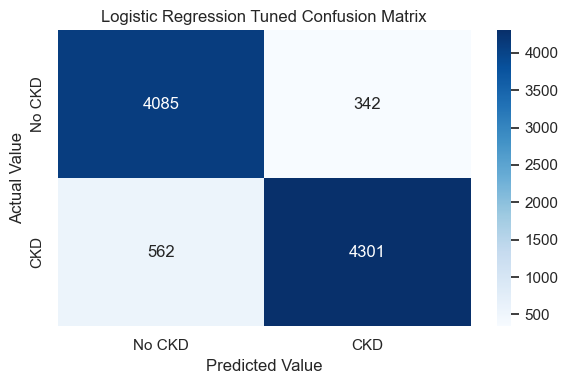

Random Forest Tuned Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4427
           1       0.93      0.87      0.90      4863

    accuracy                           0.90      9290
   macro avg       0.90      0.90      0.90      9290
weighted avg       0.90      0.90      0.90      9290



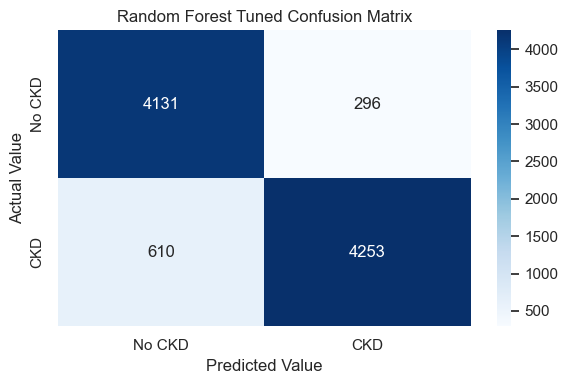

XGBoost Tuned Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4427
           1       0.94      0.89      0.91      4863

    accuracy                           0.91      9290
   macro avg       0.91      0.91      0.91      9290
weighted avg       0.91      0.91      0.91      9290



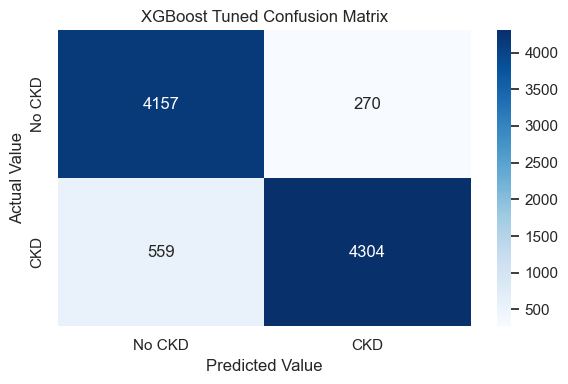

In [9]:
# Retrieve best tuned models from GridSearchCV.
logisticRegressionTunedModel = logisticRegressionGridSearch.best_estimator_
randomForestTunedModel = randomForestGridSearch.best_estimator_
xGBoostTunedModel = xGBoostGridSearch.best_estimator_

# Evaluate tuned models on the same test set.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    logisticRegressionTunedResults, logisticRegressionTunedPredictions = evaluateTunedModel(
        "Logistic Regression",
        logisticRegressionTunedModel,
        XTestScaled,
        yTest
    )

randomForestTunedResults, randomForestTunedPredictions = evaluateTunedModel(
    "Random Forest",
    randomForestTunedModel,
    XTest,
    yTest
)

xGBoostTunedResults, xGBoostTunedPredictions = evaluateTunedModel(
    "XGBoost",
    xGBoostTunedModel,
    XTest,
    yTest
)

In [10]:
# Save the tuned models and their evaluation results into a csv file.
joblib.dump(logisticRegressionTunedModel, "models/logisticRegressionModelTuned.pkl")
joblib.dump(randomForestTunedModel, "models/randomForestModelTuned.pkl")
joblib.dump(xGBoostTunedModel, "models/xgBoostModelTuned.pkl")

tunedModelResults = pd.DataFrame([
    logisticRegressionTunedResults,
    randomForestTunedResults,
    xGBoostTunedResults
])

tunedModelResults.to_csv("outputs/tunedModelResults.csv", index=False)

tunedModelResults

,modelName,accuracy,precision,recall,f1Score,rocAuc
0,Logistic Regression,0.902691,0.926341,0.884433,0.904902,0.960701
1,Random Forest,0.902476,0.934931,0.874563,0.903740,0.961644
2,XGBoost,0.910764,0.940971,0.885050,0.912154,0.966532


#### Compare the original saved model results against the tuned model results and calculate metric improvements.

In [11]:
# Load original model results and keep only the metrics required for comparison.
metricColumns = ["accuracy", "precision", "recall", "f1Score", "rocAuc"]

originalModelResults = pd.read_csv("outputs/modelResults.csv")[["modelName"] + metricColumns]
originalModelResults["modelType"] = "Original"

tunedModelResultsForComparison = tunedModelResults[["modelName"] + metricColumns].copy()
tunedModelResultsForComparison["modelType"] = "Tuned"

# Combine original and tuned model results for comparison and save to a CSV file.
comparisonData = pd.concat(
    [originalModelResults, tunedModelResultsForComparison],
    ignore_index=True
)
comparisonData.to_csv("outputs/originalVsTunedModelResults.csv", index=False)

comparisonData

,modelName,accuracy,precision,recall,f1Score,rocAuc,modelType
0,Logistic Regression,0.902906,0.926006,0.885256,0.905172,0.960720,Original
1,Random Forest,0.903014,0.935768,0.874769,0.904241,0.959727,Original
2,XGBoost,0.907966,0.940053,0.880321,0.909207,0.965443,Original
3,Logistic Regression,0.902691,0.926341,0.884433,0.904902,0.960701,Tuned
4,Random Forest,0.902476,0.934931,0.874563,0.903740,0.961644,Tuned
5,XGBoost,0.910764,0.940971,0.885050,0.912154,0.966532,Tuned


In [12]:
# Calculate how much each metric changed after tuning.
originalIndexed = originalModelResults.set_index("modelName")[metricColumns]
tunedIndexed = tunedModelResultsForComparison.set_index("modelName")[metricColumns]

improvementData = (tunedIndexed - originalIndexed).reset_index()

improvementData

,modelName,accuracy,precision,recall,f1Score,rocAuc
0,Logistic Regression,-0.000215,0.000335,-0.000823,-0.000270,-0.000018
1,Random Forest,-0.000538,-0.000837,-0.000206,-0.000501,0.001917
2,XGBoost,0.002799,0.000918,0.004730,0.002948,0.001088


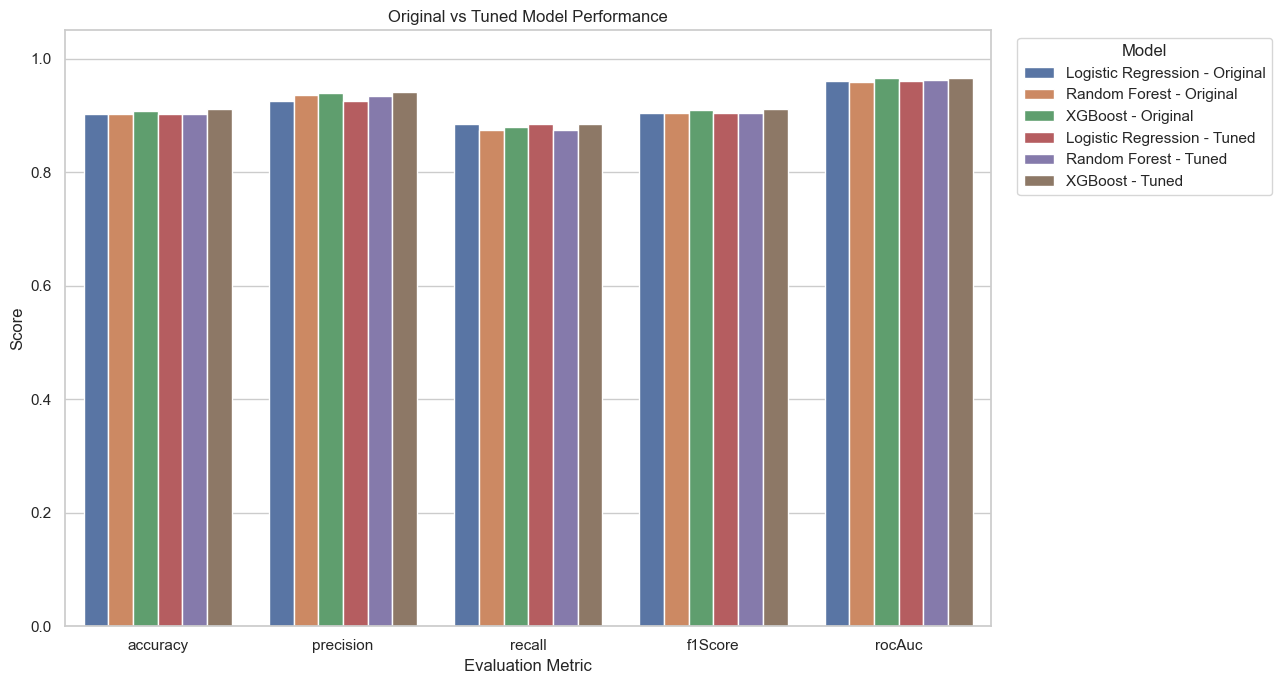

In [13]:
# Create one grouped bar chart comparing original and tuned model results.
comparisonLong = comparisonData.melt(
    id_vars=["modelName", "modelType"],
    value_vars=metricColumns,
    var_name="metric",
    value_name="score"
)

comparisonLong["modelLabel"] = comparisonLong["modelName"] + " - " + comparisonLong["modelType"]

plt.figure(figsize=(13, 7))
sns.barplot(
    data=comparisonLong,
    x="metric",
    y="score",
    hue="modelLabel"
)
plt.title("Original vs Tuned Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()